In [1]:
import tensorflow as tf

/Users/sita/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
#load the MNIST dataset - it is a set of handwritten digits(0 to 9). used to train models for handwriting recognition
data = tf.keras.datasets.mnist
(ip_train, op_train), (ip_test, op_test) = data.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
#prepare the data. already prepared data. but normalize the data
ip_train, ip_test = ip_train/255.0, ip_test/255.0

In [8]:
#build the neural network 
#flatten the input images (make them one-dimensional) ,after add one dense layer. this layer uses Softmax activation function
# 10 outputs so number of neurons is 10
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)), 
    tf.keras.layers.Dense(10, activation='softmax')
    ])

/Users/sita/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
#compile the model by selecting the loss function, optimizer and the metrics
#loss functions : binary_crossentropy (default), categorical_crossentropy(multi class classification), spares_categorical_crossentropy(multiclass )
#opitmizer - used to alter the value of the weights in order to minimized the loss function

#metrics - to check on the steps 

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [10]:
#view the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#train the model 
#epoch = is one full cycle of passing the entier data through the model
model.fit(ip_train, op_train, epochs=6)

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 291us/step - accuracy: 0.8159 - loss: 0.7138
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 279us/step - accuracy: 0.9144 - loss: 0.3055
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 278us/step - accuracy: 0.9223 - loss: 0.2799
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 277us/step - accuracy: 0.9244 - loss: 0.2721
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 277us/step - accuracy: 0.9273 - loss: 0.2626
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 292us/step - accuracy: 0.9274 - loss: 0.2608


In [13]:
#test the model 
model.evaluate(ip_test, op_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - accuracy: 0.9171 - loss: 0.3010


[0.26659196615219116, 0.9279000163078308]

In [14]:
#carry out inference 
import matplotlib.pyplot as plt
%matplotlib inline

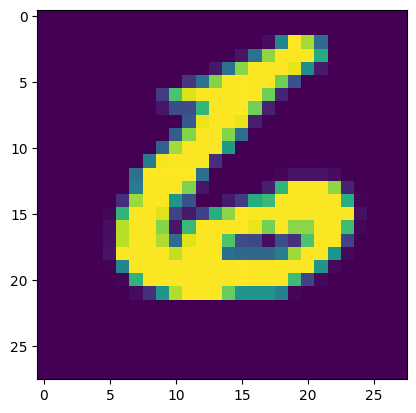

In [15]:
test_image = ip_test[9999]
plt.imshow(test_image.reshape(28,28))

In [16]:
#cross check the image 
import numpy as np 
from tensorflow.keras.preprocessing import image 
#convert the image into a numpy array 
test_image = image.img_to_array(test_image)
#reshape the test image
test_image =test_image.reshape(1,28,28)
#store the model prediction 
result = model.predict(test_image)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[7.7321948e-07, 1.2265373e-14, 6.2045081e-05, 3.5514960e-09,
        1.0698638e-07, 2.7073793e-05, 9.9990988e-01, 7.9708945e-13,
        3.8720714e-08, 5.2584156e-11]], dtype=float32)

In [20]:
#round of results 
result2 =np.around(result)
result2
#find the element that gives maximum value among all the elements of array 
(np.around(result2)).argmax()

np.int64(6)